#### BurstDECONV results analysis

In [2]:
import numpy as np

import pandas as pd
df = pd.read_csv("../../synthetic_data/svm/bd/results/test_labels_linear.csv")

In [3]:
import pandas as pd
from pathlib import Path

base_dir = Path("../../synthetic_data/svm/bd/data_ms_all")

fits = {
    "fit2":   "fit2_results.xlsx",
    "fit3M1": "fit3M1_results.xlsx",
    "fit3M2": "fit3M2_results.xlsx",
}

obj = {k: [] for k in fits}   # obj["fit2"] = [gene1..gene10 Obj[0], ...]
ks  = {k: [] for k in fits}   # ks["fit2"]  = [gene1..gene10 KS[0], ...]

genes = [f"gene{g}test" for g in range(1, 101)]

for gene in genes:
    gene_dir = base_dir / gene / "output" / f"Results{gene}"
    for fit_name, fname in fits.items():
        dfg = pd.read_excel(gene_dir / fname)
        obj[fit_name].append(dfg.loc[0, "Obj"])
        ks[fit_name].append(dfg.loc[0, "KS test"])

In [5]:
def bd_ms(obj2, ks2, obj3, ks3, alpha=0.05, improve_ratio=0.8):
    """
    Return: "fit2", "fit3M1", or "no_model_passes_KS"
    Rules:
      1) Filter by KS: keep only models with KS >= alpha
      2) If only one passes -> pick it
      3) If both pass -> pick fit3M1 only if it improves enough:
           obj3 <= improve_ratio*obj2
         else pick fit2
    """
    pass2 = ks2 >= alpha
    pass3 = ks3 >= alpha

    if not pass2 and not pass3:
        return np.nan
    if pass2 and not pass3:
        return 0
    if pass3 and not pass2:
        return 1

    # both pass
    if (obj3 <= improve_ratio * obj2):
        return 1
    return 0


decisions = []
for i, gene in enumerate(genes):
    d = bd_ms(
        obj2=obj["fit2"][i],   ks2=ks["fit2"][i],
        obj3=obj["fit3M1"][i], ks3=ks["fit3M1"][i],
        alpha=0.05,
        improve_ratio=0.8
    )
    decisions.append(d)


#### plot

In [6]:
import pandas as pd
df = pd.read_csv("../../synthetic_data/svm/bd/results/test_labels_linear.csv")

import joblib
import numpy as np

# load saved pipeline
model = joblib.load("../../synthetic_data/svm/bd/svm_model_linear.pkl")

/home/s2059283/dart/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2059283/dart/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/s2059283/dart/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.1 when using version 1.8.0. This might lead to breakin

In [7]:
dart_acc = (df["y_true"][:100] == df["y_pred"][:100]).mean()
bd_acc = (df["y_true"].iloc[:100].values == decisions[:100]).mean()

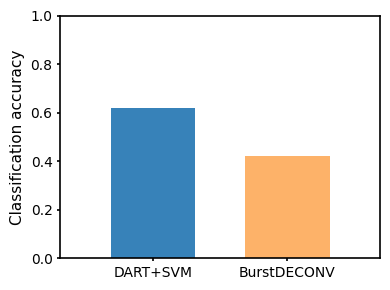

In [9]:
import matplotlib.pyplot as plt
labels = ["DART+SVM", "BurstDECONV"]
values = [dart_acc,bd_acc]

fig, ax = plt.subplots(figsize=(4,3))                   
x = np.array([0, 0.4])
wd = 0.25

ax.bar(
    x, values,
    width=wd,                    # thinner bars
    color=["#2c7bb6", "#fdae61"],   # two colors
    alpha=0.95
)
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_xlim(x[0] - wd*1.1, x[-1] + wd*1.1)
ax.margins(x=0)  

ax.set_ylabel("Classification accuracy", fontsize=11)

for side in ["left", "bottom", "top", "right"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)

# thicker ticks
ax.tick_params(axis="both", width=1.2, length=2, labelsize=10)

ax.set_ylim(0, 1)

plt.tight_layout()
#fig.savefig("Figures/figs/dart1_bd_acc.pdf", bbox_inches="tight", dpi=300)